<a href="https://colab.research.google.com/github/GabCAD92/Machine-learning-tasks/blob/main/Classification_and_Regression_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning
## Supervised Learning: Classification and Regression Exercises

This lesson introduces __Multilayer Perceptrons (MLPs)__ and __Backpropagation__ using __SKLearn__ applyied to a __Classification__ task.


### Professor:

<img src="https://www.sorocaba.unesp.br/Home/Graduacao/EngenhariadeControleeAutomacao/alexandre/alex_marta1_small.jpg" width="100" style="float: left; margin-right: 5px;" border="10px" />

  __Prof. Dr. Alexandre da Silva Simões__ <br>
  Department of Control and Automation Engineering (DECA) <br>
  Institute of Science and Technology of Sorocaba (ICTS) <br>
  São Paulo State University (Unesp) <br>
  www.sorocaba.unesp.br/professor/assimoes

<br/>

Based on:
* Géron, A. "Hands-On Machine Learning with Scikit-Learn and TensorFlow", O’Reilly Media Inc., Sebastopol, CA, EUA.
* Simões, A. S. Segmentação de imanges por classificação de cores: uma abordagem neural. Dissertação (mestrado). Escola Politécnica. Universidade de São Paulo. São Paulo, 2000.


# Table of Contents


1. General overview <br>
   1.1. The wine quality dataset <br>
   1.2. Data split <br>
 <br>
2. Logistic Regression <br>
   2.1. **Exercise 1**: binary output <br>
   2.2. **Exercise 2**: ROC curve <br>
   2.2. **Exercise 3**: multiclass classifier <br>
   <br>
3. Artificial Neural Netorks (ANNs)<br>
   3.1. **Exercise 4**: MLP sequential classification <br>
   3.2. **Exercise 5**: MLP one-of-c classification (one-hot encoding) <br>
   <br>
4. Regressions <br>
   4.1. **Exercise 6**: Linear Regression <br>
   4.2. **Exercise 7**: Polynomial Regression <br>
   4.3. **Exercise 8**: MLP Regression <br>
   <br>
5. Models comparison <br>
   5.1. **Exercise 9**: test set comparison <br>


____

## 1. General Overview

<img src="https://drive.google.com/uc?id=1BmjoJ_sBuRcnj4-J1fWJiKM8h3aYuOTV" width="400" style="float: left; margin-right: 5px;" border="0px" />

### 1.1 The wine quality dataset

The two available datasets collect data related to red and white variants of the Portuguese "Vinho Verde" wine [Cortez et al., 2009]. Physicochemical (inputs) and sensory (the output) variables are available. Source: https://archive.ics.uci.edu/ml/datasets/Wine+Quality

These datasets can be viewed as classification or regression tasks. The classes are ordered and not balanced (e.g. there are many more normal wines than excellent or poor ones). Outlier detection algorithms could be used to detect the few excellent or poor wines. Also, we are not sure if all input variables are relevant. So it could be interesting to test feature selection methods.

* Number of Instances: 4898 <br>
* Number of input variables: 11 <br>
* Number of output variables: 1 <br>

Input variables (based on physicochemical tests):
1. fixed acidity
2. volatile acidity
3. citric acid
4. residual sugar
5. chlorides
6. free sulfur dioxide
7. total sulfur dioxide
8. density
9. pH
10. sulphates
11. alcohol

Output variable (based on sensory data):
12. quality (score between 0 and 10)

<img src="https://drive.google.com/uc?id=1QYLD943YCzf9wJpJ6cKHHni4eD41fyQE" width="500" style="float: left; margin-right: 5px;" border="0px" />

Reference:

P. Cortez, A. Cerdeira, F. Almeida, T. Matos and J. Reis. Modeling wine preferences by data mining from physicochemical properties. Decision Support Systems, Elsevier, 47(4):547-553, 2009. <br/>
<br/>

### 1.2. Data split

<img src="https://drive.google.com/uc?id=1nBqIrCItK32DIgiB29g4_xaRMHujk7wZ" width="400" style="float: left; margin-right: 5px;" border="0px" />

In this notebook we will adopt the proportion **60:20:20** to split the available data between the training, validation and test sets. Training and validation sets will be used to train/validate your models. **The test set can only be used to compare the final models!!!!!**

___

## 2. Logistic Regression

<img src="https://drive.google.com/uc?id=1DWg7HDN8IE6Tv8KAn2FXoYC1necZM0cq" width="200" style="float: left; margin-right: 5px;" border="0px" />

### 2.1. Exercise 1: binary output

Initially, let's try to classify only the best wines. Consider that **red wines** and **white wines** with scores 8, 9 and 10 are the "best wines" (class=1). All the remaining scores are "regular wines" (class=0). Implement a binary logistic regression (one for each wine type) that can classify your data. Remember that you must previously prepare your data! Present the **Confision Matrix** for your validation set.


RED WINE MODEL


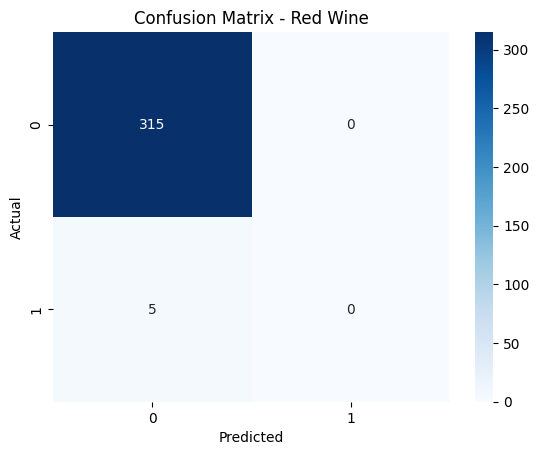

WHITE WINE MODEL


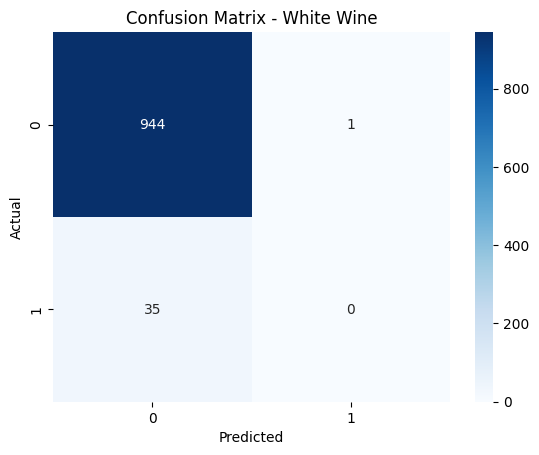

In [ ]:
# =========================================
# 1. Import Libraries
# =========================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

# =========================================
# 2. Load Dataset
# =========================================
red = pd.read_csv('winequality-red.csv', sep=';')
white = pd.read_csv('winequality-white.csv', sep=';')

# =========================================
# 3. Create Binary Target
# =========================================
def create_binary_target(df):
    df = df.copy()
    df['best'] = df['quality'].apply(lambda x: 1 if x >= 8 else 0)
    return df

red = create_binary_target(red)
white = create_binary_target(white)

# =========================================
# 4. Function to Train Model
# =========================================
def train_logistic_model(data, title):

    X = data.drop(['quality', 'best'], axis=1)
    y = data['best']

    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Scale
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Train Logistic Regression
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {title}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    return cm

# =========================================
# 5. Train Models
# =========================================
print("RED WINE MODEL")
cm_red = train_logistic_model(red, "Red Wine")

print("WHITE WINE MODEL")
cm_white = train_logistic_model(white, "White Wine")

### 2.2. Exercise 2: ROC curve

Evaluate the classifier trained above using a ROC curve. OBS: there are two methods that you can use to predict the output class: 1) predict (the output will be the class label: 0 or 1 in our case); 2) predict_proba (the output will be the probability, that is, a value between 0 and 1 for each class). The ROC curve can display the model performance for distinct cut points (thersholds) of predict_proba.   

RED WINE ROC


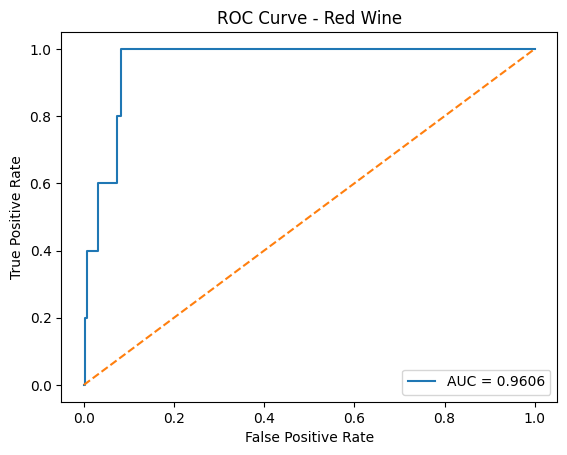

WHITE WINE ROC


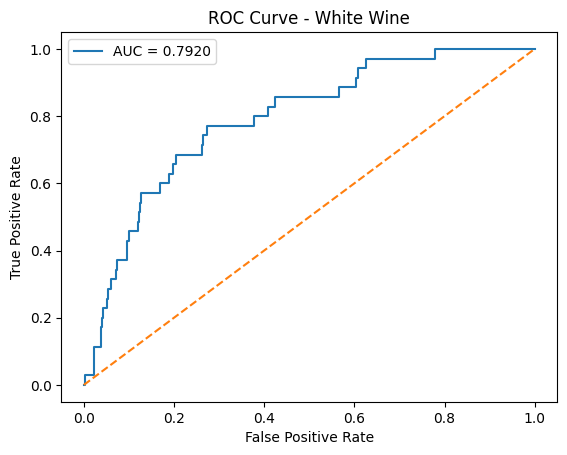


Red Wine AUC: 0.9606
White Wine AUC: 0.7920


In [ ]:
# =========================================
# 1. Import Libraries
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc

# =========================================
# 2. Load Dataset
# =========================================
red = pd.read_csv('winequality-red.csv', sep=';')
white = pd.read_csv('winequality-white.csv', sep=';')

# =========================================
# 3. Create Binary Target
# =========================================
def prepare_data(df):
    df = df.copy()
    df['best'] = df['quality'].apply(lambda x: 1 if x >= 8 else 0)

    X = df.drop(['quality', 'best'], axis=1)
    y = df['best']

    return X, y

# =========================================
# 4. Function to Train + ROC
# =========================================
def plot_roc(X, y, title):

    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Scale
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Train model
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    # Get probabilities (IMPORTANT)
    y_prob = model.predict_proba(X_test)[:, 1]

    # ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    # Plot
    plt.figure()
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
    plt.plot([0,1], [0,1], linestyle='--')  # random model line
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {title}')
    plt.legend()
    plt.show()

    return roc_auc

# =========================================
# 5. Run for Both Datasets
# =========================================
X_red, y_red = prepare_data(red)
X_white, y_white = prepare_data(white)

print("RED WINE ROC")
auc_red = plot_roc(X_red, y_red, "Red Wine")

print("WHITE WINE ROC")
auc_white = plot_roc(X_white, y_white, "White Wine")

print(f"\nRed Wine AUC: {auc_red:.4f}")
print(f"White Wine AUC: {auc_white:.4f}")

### 2.3. Exercise 3: multiclass classifier

Now let's consider all the 1-10 score. Implement a multiclass logistic regression (one for each wine type) that can classify your data. Present the **Confision Matrix** for your validation set.

RED WINE MULTICLASS MODEL


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


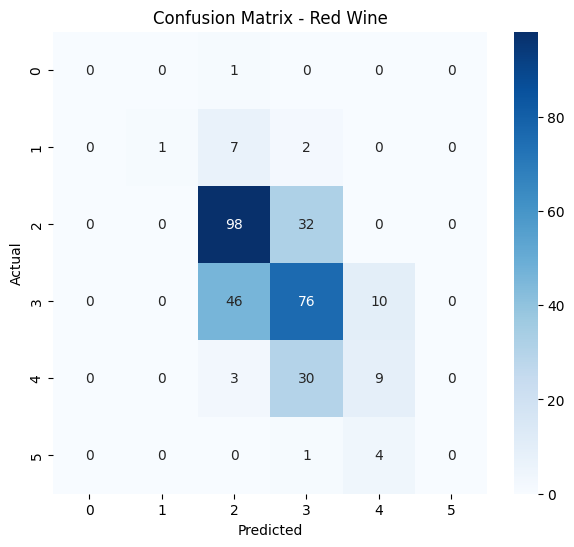

WHITE WINE MULTICLASS MODEL


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


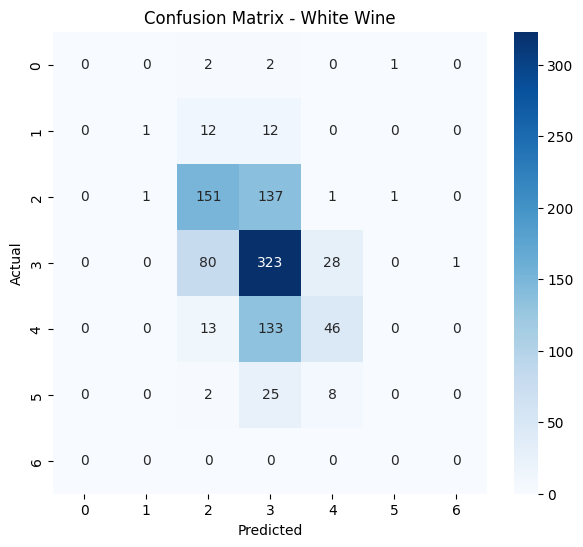

In [ ]:
# =========================================
# 1. Import Libraries
# =========================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

# =========================================
# 2. Load Dataset
# =========================================
red = pd.read_csv('winequality-red.csv', sep=';')
white = pd.read_csv('winequality-white.csv', sep=';')

# =========================================
# 3. Function to Train Multiclass Model
# =========================================
def train_multiclass_model(data, title):

    X = data.drop('quality', axis=1)
    y = data['quality']  # multiclass target

    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Scale
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Multiclass Logistic Regression
    model = LogisticRegression(
        multi_class='multinomial',
        solver='lbfgs',
        max_iter=2000
    )

    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot
    plt.figure(figsize=(7,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {title}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    return cm

# =========================================
# 4. Train for Both Datasets
# =========================================
print("RED WINE MULTICLASS MODEL")
cm_red = train_multiclass_model(red, "Red Wine")

print("WHITE WINE MULTICLASS MODEL")
cm_white = train_multiclass_model(white, "White Wine")

Confision Matrix Example:

<img src="https://drive.google.com/uc?id=1WekrrR4UZHNiutRhztqs6zDP3MLKpYy5" width="500" style="float: left; margin-right: 5px;" border="0px" />


Source: P. Cortez, A. Cerdeira, F. Almeida, T. Matos and J. Reis. Modeling wine preferences by data mining from physicochemical properties. Decision Support Systems, Elsevier, 47(4):547-553, 2009.

____

## 3. Artificial Neural Networks (ANN)

### 3.1. Exercise 4: MLP sequential classification

<img src="https://drive.google.com/uc?id=1dpVcFSmDcxi75G37VsQ6kI6VYxjmqhS6" width="500" style="float: left; margin-right: 5px;" border="0px" />

Now let's adopt a multilayer perceptron (MLP) that can learn the 1-10 classification using the **sequential** classification. Select the best parameters for your classifier (number of layers, number of neurons in hidden layers, activation function, learning rate). After a sucessfull training, present the **Confusion Matrix** for your validation set.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8562 - loss: 0.6206 - val_accuracy: 0.9312 - val_loss: 0.2188
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9625 - loss: 0.1273 - val_accuracy: 0.9312 - val_loss: 0.1849
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9625 - loss: 0.0959 - val_accuracy: 0.9438 - val_loss: 0.1321
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9672 - loss: 0.0808 - val_accuracy: 0.9563 - val_loss: 0.0892
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9766 - loss: 0.0631 - val_accuracy: 0.9375 - val_loss: 0.1334
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9734 - loss: 0.0570 - val_accuracy: 0.9688 - val_loss: 0.0847
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9859 - loss: 0.0518 - val_accuracy: 0.9750 - val_loss: 0.0760
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9844 - loss: 0.0441 - val_accuracy: 0.9688 - val_loss:

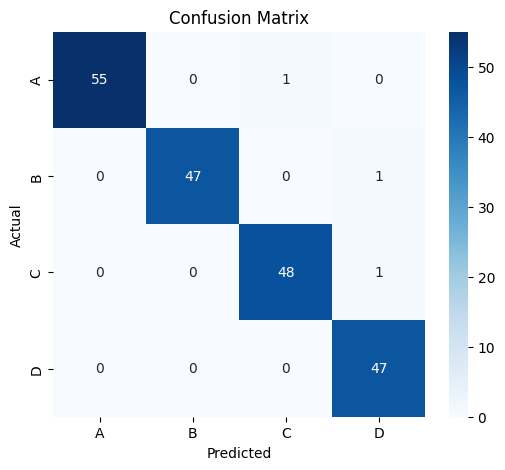


Classification Report:
              precision    recall  f1-score   support

           A       1.00      0.98      0.99        56
           B       1.00      0.98      0.99        48
           C       0.98      0.98      0.98        49
           D       0.96      1.00      0.98        47

    accuracy                           0.98       200
   macro avg       0.98      0.99      0.98       200
weighted avg       0.99      0.98      0.99       200



In [ ]:
# ==============================
# 1. Import Libraries
# ==============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# ==============================
# 2. Create Synthetic Dataset
# ==============================
# Example dataset (you can replace with your own)
np.random.seed(42)

X = np.random.rand(1000, 3)  # 3 input features

# Create labels based on simple logic (like your table idea)
y = []
for row in X:
    if row[0] < 0.5 and row[1] < 0.5:
        y.append(0)  # A
    elif row[0] < 0.5 and row[1] >= 0.5:
        y.append(1)  # B
    elif row[0] >= 0.5 and row[1] < 0.5:
        y.append(2)  # C
    else:
        y.append(3)  # D

y = np.array(y)

# ==============================
# 3. Train-Test Split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# 4. Feature Scaling
# ==============================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==============================
# 5. Build MLP Model
# ==============================
model = Sequential([
    Dense(16, activation='relu', input_shape=(X.shape[1],)),
    Dense(16, activation='relu'),
    Dense(4, activation='softmax')  # 4 classes
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ==============================
# 6. Train Model
# ==============================
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

# ==============================
# 7. Evaluate Model
# ==============================
loss, acc = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {acc:.4f}")

# ==============================
# 8. Predictions
# ==============================
y_pred = np.argmax(model.predict(X_test), axis=1)

# ==============================
# 9. Confusion Matrix
# ==============================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['A','B','C','D'],
            yticklabels=['A','B','C','D'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# ==============================
# 10. Classification Report
# ==============================
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['A','B','C','D']))

### 3.2. Exercise 5: MLP one-of-c-classes classification (one-hot encoding)


<img src="https://drive.google.com/uc?id=1RU56j9OeMqc_kYtwt_o8N0Wdt89mA18z" width="700" style="float: left; margin-right: 5px;" border="0px" />

Now let's adopt a multilayer perceptron (MLP) that can learn the 1-10 classification using the **one-of-10 classes** classification. Select the best parameters for your classifier (number of layers, number of neurons in hidden layers, activation function, learning rate). After a sucessfull training, present the **Confusion Matrix** for your validation set.

Epoch 1/60


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8641 - loss: 0.6983 - val_accuracy: 0.9187 - val_loss: 0.2670
Epoch 2/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9609 - loss: 0.1479 - val_accuracy: 0.9625 - val_loss: 0.1263
Epoch 3/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9766 - loss: 0.0935 - val_accuracy: 0.9563 - val_loss: 0.1118
Epoch 4/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9828 - loss: 0.0722 - val_accuracy: 0.9563 - val_loss: 0.0977
Epoch 5/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9859 - loss: 0.0586 - val_accuracy: 0.9563 - val_loss: 0.1143
Epoch 6/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9594 - loss: 0.0920 - val_accuracy: 0.9625 - val_loss: 0.0892
Epoch 7/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9781 - loss: 0.0641 - val_accuracy: 0.9688 - val_loss: 0.0750
Epoch 8/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9906 - loss: 0.0439 - val_accuracy: 0.9625 - val_loss: 0.0849
Epo

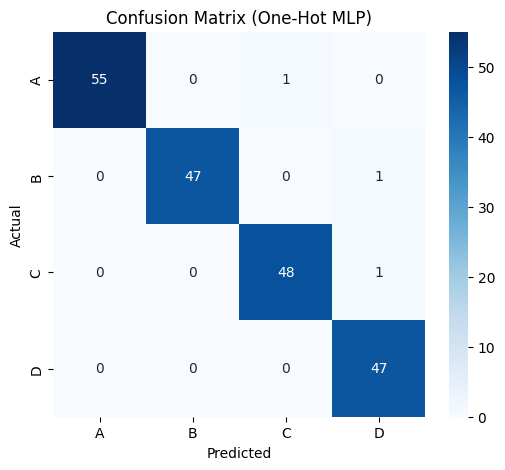


Classification Report:
              precision    recall  f1-score   support

           A       1.00      0.98      0.99        56
           B       1.00      0.98      0.99        48
           C       0.98      0.98      0.98        49
           D       0.96      1.00      0.98        47

    accuracy                           0.98       200
   macro avg       0.98      0.99      0.98       200
weighted avg       0.99      0.98      0.99       200



In [ ]:
# ==============================
# 1. Import Libraries
# ==============================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# ==============================
# 2. Create Dataset
# ==============================
np.random.seed(42)

X = np.random.rand(1000, 3)

# Create class labels (0,1,2,3)
y = []
for row in X:
    if row[0] < 0.5 and row[1] < 0.5:
        y.append(0)  # A
    elif row[0] < 0.5 and row[1] >= 0.5:
        y.append(1)  # B
    elif row[0] >= 0.5 and row[1] < 0.5:
        y.append(2)  # C
    else:
        y.append(3)  # D

y = np.array(y)

# ==============================
# 3. One-Hot Encoding
# ==============================
y_encoded = to_categorical(y, num_classes=4)

# ==============================
# 4. Train-Test Split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

# ==============================
# 5. Feature Scaling
# ==============================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==============================
# 6. Build MLP Model
# ==============================
model = Sequential([
    Dense(32, activation='relu', input_shape=(X.shape[1],)),
    Dense(32, activation='relu'),
    Dense(4, activation='softmax')  # 4 output neurons (one-hot)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
    loss='categorical_crossentropy',  # IMPORTANT for one-hot
    metrics=['accuracy']
)

# ==============================
# 7. Train Model
# ==============================
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=60,
    batch_size=16,
    verbose=1
)

# ==============================
# 8. Evaluate Model
# ==============================
loss, acc = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {acc:.4f}")

# ==============================
# 9. Predictions
# ==============================
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# ==============================
# 10. Confusion Matrix
# ==============================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['A','B','C','D'],
            yticklabels=['A','B','C','D'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (One-Hot MLP)')
plt.show()

# ==============================
# 11. Classification Report
# ==============================
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['A','B','C','D']))

___

## 4. Regressions

### 4.1. Exercise 6: Linear Regression

<img src="https://drive.google.com/uc?id=12Ozjkf4jbaDYFV-cJA_89z1rn9-Zp526" width="300" style="float: left; margin-right: 5px;" border="0px" />


Assume that we are modeling the problem using a **linear regression**. Train your system using suitable parameters and present the MAE, MSE and R2 score for your validation set.  



In [ ]:
# ==============================
# 1. Import Libraries
# ==============================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==============================
# 2. Load Dataset
# ==============================
# Make sure files are uploaded in Colab
red = pd.read_csv('winequality-red.csv', sep=';')
white = pd.read_csv('winequality-white.csv', sep=';')

# Combine both datasets
data = pd.concat([red, white], axis=0)

print("Dataset shape:", data.shape)
print(data.head())

# ==============================
# 3. Define Features & Target
# ==============================
X = data.drop('quality', axis=1)
y = data['quality']

# ==============================
# 4. Train-Test Split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# 5. Train Linear Regression Model
# ==============================
model = LinearRegression()
model.fit(X_train, y_train)

# ==============================
# 6. Predictions
# ==============================
y_pred = model.predict(X_test)

# ==============================
# 7. Evaluation Metrics
# ==============================
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("\nModel Performance:")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"R2 Score: {r2:.4f}")

Dataset shape: (6497, 12)
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8      

### 4.2. Exercise 7: Polynomial Regression

<img src="https://drive.google.com/uc?id=1nB_GWb_f8pPAkjxedGW-rUlZWyjBfi9T" width="300" style="float: left; margin-right: 5px;" border="0px" />

Assume that we are modeling the problem using a **polynomial regression**. Train your system using suitable parameters (including the polynomial degree) and present the MAE, MSE and R2 score for your validation set.  



In [ ]:
# =========================================
# 1. Import Libraries
# =========================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================================
# 2. Load Dataset
# =========================================
red = pd.read_csv('winequality-red.csv', sep=';')
white = pd.read_csv('winequality-white.csv', sep=';')

data = pd.concat([red, white], axis=0)

# =========================================
# 3. Features & Target
# =========================================
X = data.drop('quality', axis=1)
y = data['quality']

# =========================================
# 4. Train-Test Split
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================================
# 5. Feature Scaling
# =========================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================================
# 6. Polynomial Degree Selection
# =========================================
degrees = [2, 3]
best_degree = None
best_r2 = -np.inf

for d in degrees:
    poly = PolynomialFeatures(degree=d)
    X_train_poly = poly.fit_transform(X_train_scaled)
    X_test_poly = poly.transform(X_test_scaled)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    y_pred = model.predict(X_test_poly)

    r2 = r2_score(y_test, y_pred)

    print(f"\nDegree {d} → R2: {r2:.4f}")

    if r2 > best_r2:
        best_r2 = r2
        best_degree = d

print(f"\nBest Polynomial Degree: {best_degree}")

# =========================================
# 7. Train Final Model with Best Degree
# =========================================
poly = PolynomialFeatures(degree=best_degree)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

model = LinearRegression()
model.fit(X_train_poly, y_train)

# =========================================
# 8. Final Predictions
# =========================================
y_pred = model.predict(X_test_poly)

# =========================================
# 9. Evaluation Metrics
# =========================================
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("\n===== FINAL MODEL PERFORMANCE =====")
print(f"Polynomial Degree: {best_degree}")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"R2 Score: {r2:.4f}")


Degree 2 → R2: 0.2418

Degree 3 → R2: -0.8352

Best Polynomial Degree: 2

===== FINAL MODEL PERFORMANCE =====
Polynomial Degree: 2
MAE: 0.5489
MSE: 0.5600
R2 Score: 0.2418


### 4.3. Exercise 8: MLP Regression

<img src="https://drive.google.com/uc?id=1ee25ys2HBczSR0njqOAuZx1emu9PpM7o" width="500" style="float: left; margin-right: 5px;" border="0px" />

Assume that we are using an MLP configured as a regressor, that is, in this case with only one neuron configured with a linear activation function in the output layer that will give us the wine grade. Train the ANN, and present the MAE, MSE and R2 score for your validation set.  

In [ ]:
# =========================================
# 1. Import Libraries
# =========================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# =========================================
# 2. Load Dataset
# =========================================
red = pd.read_csv('winequality-red.csv', sep=';')
white = pd.read_csv('winequality-white.csv', sep=';')

data = pd.concat([red, white], axis=0)

# =========================================
# 3. Features & Target
# =========================================
X = data.drop('quality', axis=1)
y = data['quality']

# =========================================
# 4. Train-Test Split
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================================
# 5. Feature Scaling (VERY IMPORTANT for ANN)
# =========================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================================
# 6. Build MLP Regressor
# =========================================
model = Sequential([
    Dense(64, activation='relu', input_shape=(X.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')  # 🔥 KEY: single neuron, linear output
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',  # regression loss
    metrics=['mae']
)

# =========================================
# 7. Train Model
# =========================================
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)

# =========================================
# 8. Predictions
# =========================================
y_pred = model.predict(X_test_scaled).flatten()

# =========================================
# 9. Evaluation Metrics
# =========================================
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("\n===== MLP REGRESSION PERFORMANCE =====")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"R2 Score: {r2:.4f}")

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 8.4937 - mae: 2.2978 - val_loss: 2.0471 - val_mae: 1.0681
Epoch 2/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.6606 - mae: 1.0042 - val_loss: 1.5414 - val_mae: 0.9361
Epoch 3/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.2986 - mae: 0.8896 - val_loss: 1.2292 - val_mae: 0.8469
Epoch 4/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0474 - mae: 0.7989 - val_loss: 0.9716 - val_mae: 0.7547
Epoch 5/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8514 - mae: 0.7176 - val_loss: 0.8101 - val_mae: 0.6852
Epoch 6/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7078 - mae: 0.6567 - val_loss: 0.6868 - val_mae: 0.6270
Epoch 7/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6241 - mae: 0.6121 - val_loss: 0.5922 - val_mae: 0.5815
Epoch 8/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5743 - mae: 0.5886 - val_loss: 0.5632 - val_mae: 0.5726
Epoch 9/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss:

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

===== MLP REGRESSION PERFORMANCE =====
MAE: 0.5559
MSE: 0.5304
R2 Score: 0.2818


___

## 5. Models comparison

### 5.1.Test set comparison

Compare the performance of all your systems (exercise 1-8) using the **test set**.


In [6]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Upload file
from google.colab import files
uploaded = files.upload()


Saving winequality-red.csv to winequality-red (3).csv
Saving winequality-white.csv to winequality-white (2).csv


In [7]:
df = pd.read_csv("winequality-red.csv")
df.head()

,"fixed acidity;""volatile acidity"";""citric acid"";""residual sugar"";""chlorides"";""free sulfur dioxide"";""total sulfur dioxide"";""density"";""pH"";""sulphates"";""alcohol"";""quality"""
0,7.4;0.7;0;1.9;0.076;11;34;0.9978;3.51;0.56;9.4;5
1,7.8;0.88;0;2.6;0.098;25;67;0.9968;3.2;0.68;9.8;5
2,7.8;0.76;0.04;2.3;0.092;15;54;0.997;3.26;0.65;...
3,11.2;0.28;0.56;1.9;0.075;17;60;0.998;3.16;0.58...
4,7.4;0.7;0;1.9;0.076;11;34;0.9978;3.51;0.56;9.4;5


In [9]:
# Load correctly
df = pd.read_csv("winequality-red.csv", sep=';')

# Check columns
print(df.columns)

# Prepare data
X = df.drop("quality", axis=1)
y = df["quality"]

# Split into Train (70%) and Test (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')


In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "SVR": SVR()
}

In [12]:
results = []

for name, model in models.items():

    if name == "SVR":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append([name, mae, mse, r2])

In [13]:
results_df = pd.DataFrame(results, columns=["Model", "MAE", "MSE", "R2"])
results_df = results_df.sort_values(by="R2", ascending=False)

print("=== TEST SET COMPARISON ===")
print(results_df)

=== TEST SET COMPARISON ===
               Model       MAE       MSE        R2
2      Random Forest  0.438771  0.342826  0.459286
3                SVR  0.470831  0.375111  0.408365
0  Linear Regression  0.513396  0.411235  0.351389
1      Decision Tree  0.483333  0.658333 -0.038342


____
<center>
<img src="https://upload.wikimedia.org/wikipedia/commons/0/0a/Logo_Unesp.svg" width="400" style="float: left; margin-right: 5px;" border="0px" />
</center>